# Modelo 1 — CNN 1D (Baseline)
**Referência:** Pavlovic et al. (2021). *Sensors*, 21, 4050.  
**Dataset:** https://doi.org/10.5281/zenodo.4064801

### Pipeline
1. Importações e configuração
2. Carregamento e fusão dos dados
3. Pré-processamento
4. Divisão treino / teste
5. Definição da CNN
6. Treinamento com validação cruzada (5-fold)
7. Avaliação no conjunto de teste

---
## 1. Importações e Configuração

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report
)

print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {"cuda" if torch.cuda.is_available() else "cpu"}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')

PyTorch  : 2.11.0+rocm7.2
Device   : cuda
GPU      : AMD Radeon RX 7800 XT


In [3]:
# ── Configuração central ──────────────────────────────────────────────────────
# Ajustar PASTA_DATASET para o caminho onde estão os CSVs no seu computador
PASTA_DATASET = Path('../dataset')

# Ajustar os caminhos abaixo para onde deve ser salvo os checkpoints, figuras e métricas
PASTA_CHECKPOINTS = Path('../results/checkpoints')
PASTA_FIGURES     = Path('../results/figures')
PASTA_METRICS     = Path('../results/metrics')

# Criar as pastas se não existirem
for p in [PASTA_CHECKPOINTS, PASTA_FIGURES, PASTA_METRICS]:
    p.mkdir(parents=True, exist_ok=True)

# Frequência de amostragem (Hz)
FREQ_HZ = 10

# Tamanho da janela temporal (segundos)
TAMANHO_JANELA_S = 90
AMOSTRAS_POR_JANELA = TAMANHO_JANELA_S * FREQ_HZ  # 900 amostras

# IDs de todos os animais
TODOS_IDS = [f'{i:02d}' for i in range(1, 19)]

# Animais reservados para teste (1 por farm trial — conforme artigo)
IDS_TESTE = ['04', '10', '11']
IDS_TREINO = [i for i in TODOS_IDS if i not in IDS_TESTE]

# Rótulos de comportamento
CLASSES = {0: 'Outro', 1: 'Ruminação', 2: 'Comendo'}
N_CLASSES = 3

# Hiperparâmetros da CNN (Pavlovic et al., 2021)
KERNEL_SIZE  = 16
DROPOUT      = 0.25
N_FILTROS    = 64
LR           = 1e-4
WEIGHT_DECAY = 0.01
BATCH_SIZE   = 256
EPOCAS_MAX   = 50
PATIENCE     = 15
DELTA_ES     = 0.01
N_FOLDS      = 5

SEMENTE = 42
torch.manual_seed(SEMENTE)
np.random.seed(SEMENTE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Animais treino : {IDS_TREINO}')
print(f'Animais teste  : {IDS_TESTE}')
print(f'Janela         : {TAMANHO_JANELA_S}s × {FREQ_HZ}Hz = {AMOSTRAS_POR_JANELA} amostras')
print(f'Device         : {DEVICE}')

Animais treino : ['01', '02', '03', '05', '06', '07', '08', '09', '12', '13', '14', '15', '16', '17', '18']
Animais teste  : ['04', '10', '11']
Janela         : 90s × 10Hz = 900 amostras
Device         : cuda


---
## 2. Carregamento e Fusão dos Dados

Para cada animal:
- `accel-XX.csv` → dados do colar (timestamp, x, y, z) → **features**
- `halter-XX.csv` → classificação do halter (timestamp, classification) → **rótulo (ground truth)**

Os dois arquivos são unidos pelo `timestamp` com um `inner join`.

In [4]:
def carregar_animal(animal_id: str) -> pd.DataFrame:
    """
    Carrega e funde os arquivos accel e halter de um animal.

    Os dois sensores operam a 10 Hz mas com timestamps ligeiramente
    desalinhados. O arredondamento para 100ms (= 1/10 s) alinha ambos
    para a mesma grade antes do merge.
    """
    path_accel  = PASTA_DATASET / f'accel-{animal_id}.csv'
    path_halter = PASTA_DATASET / f'halter-{animal_id}.csv'

    accel  = pd.read_csv(path_accel,  parse_dates=['timestamp'])
    halter = pd.read_csv(path_halter, parse_dates=['timestamp'])

    # Arredonda para 100ms — alinha a grade de 10 Hz dos dois sensores
    accel['timestamp']  = accel['timestamp'].dt.round('100ms')
    halter['timestamp'] = halter['timestamp'].dt.round('100ms')

    accel  = accel.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
    halter = halter.rename(columns={'classification': 'rotulo'})

    df = pd.merge(accel, halter, on='timestamp', how='inner')
    df = df.sort_values('timestamp').reset_index(drop=True)
    df.insert(0, 'animal_id', animal_id)
    return df


In [5]:
# Carrega todos os animais disponíveis na pasta
dados_por_animal = {}
ids_disponiveis  = []

for aid in tqdm(TODOS_IDS, desc='Carregando animais'):
    p_accel  = PASTA_DATASET / f'accel-{aid}.csv'
    p_halter = PASTA_DATASET / f'halter-{aid}.csv'
    if p_accel.exists() and p_halter.exists():
        dados_por_animal[aid] = carregar_animal(aid)
        ids_disponiveis.append(aid)
    else:
        print(f'  [{aid}] aguardando download...')

print(f'\nAnimais carregados: {ids_disponiveis}')

Carregando animais:   0%|          | 0/18 [00:00<?, ?it/s]


Animais carregados: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18']


In [ ]:
# Diagnóstico: inspeciona os timestamps brutos do primeiro animal antes do merge para entender o desalinhamento
# Já foi feito o diagnóstico, então o código abaixo é apenas para referência e pode ser ignorado.

# aid_diag = ids_disponiveis[0]

# accel_raw  = pd.read_csv(
#     PASTA_DATASET / f'accel-{aid_diag}.csv',
#     parse_dates=['timestamp'], nrows=5
# )
# halter_raw = pd.read_csv(
#     PASTA_DATASET / f'halter-{aid_diag}.csv',
#     parse_dates=['timestamp'], nrows=5
# )

# print(f'Animal {aid_diag} — primeiros timestamps brutos:')
# print(f'\naccel  (colar):')
# print(accel_raw[['timestamp']].to_string())
# print(f'\nhalter (focinho):')
# print(halter_raw[['timestamp']].to_string())

# # Verifica se há algum timestamp em comum sem arredondamento
# accel_ts  = set(accel_raw['timestamp'])
# halter_ts = set(halter_raw['timestamp'])
# print(f'\nTimestamps em comum (sem arredondamento): {len(accel_ts & halter_ts)}')
# print('→ Se 0: confirma o desalinhamento — arredondamento para 100ms é necessário.')

In [6]:
# Inspeciona o primeiro animal disponível
aid_exemplo = ids_disponiveis[0]
df_ex = dados_por_animal[aid_exemplo]

print(f'Animal {aid_exemplo}')
print(f'  Shape         : {df_ex.shape}')
print(f'  Período       : {df_ex.timestamp.min()} → {df_ex.timestamp.max()}')
print(f'  Duração (h)   : {len(df_ex) / FREQ_HZ / 3600:.1f}')
print(f'  Dist. rótulos :')
for r, nome in CLASSES.items():
    n = (df_ex.rotulo == r).sum()
    print(f'    {r} {nome:12s}: {n:,} ({n/len(df_ex)*100:.1f}%)')

df_ex.head()

Animal 01
  Shape         : (14595853, 6)
  Período       : 2015-06-12 13:30:00.200000 → 2015-06-29 08:29:59.800000
  Duração (h)   : 405.4
  Dist. rótulos :
    0 Outro       : 5,914,328 (40.5%)
    1 Ruminação   : 5,858,813 (40.1%)
    2 Comendo     : 2,822,712 (19.3%)


,animal_id,timestamp,acc_x,acc_y,acc_z,rotulo
0,01,2015-06-12 13:30:00.200,100,620,804,2
1,01,2015-06-12 13:30:00.300,68,640,800,2
2,01,2015-06-12 13:30:00.400,48,628,884,2
3,01,2015-06-12 13:30:00.500,44,616,888,2
4,01,2015-06-12 13:30:00.600,76,628,860,2


---
## 3. Pré-processamento

### 3.1 Diferença Discreta
$$\Delta s[t] = s[t] - s[t-1], \quad \forall s \in \{x, y, z\}$$

Elimina vieses estáticos de orientação do colar (Pavlovic et al., 2021 — Eq. 1).

### 3.2 Janelamento de 90 s
Cada janela de 900 amostras recebe um único rótulo por **votação majoritária**.

### 3.3 Balanceamento por animal
Undersampling para igualar a representação das 3 classes.

In [7]:
def diferenca_discreta(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in ['acc_x', 'acc_y', 'acc_z']:
        df[col] = df[col].diff()
    return df.dropna().reset_index(drop=True)


def janelamento(df: pd.DataFrame, animal_id: str) -> list:
    janelas = []
    n_janelas = len(df) // AMOSTRAS_POR_JANELA
    for i in range(n_janelas):
        bloco  = df.iloc[i * AMOSTRAS_POR_JANELA : (i + 1) * AMOSTRAS_POR_JANELA]
        rotulo = int(bloco['rotulo'].mode()[0])  # votação majoritária
        janelas.append({
            'animal_id': animal_id,
            'rotulo': rotulo,
            'x': bloco['acc_x'].values,
            'y': bloco['acc_y'].values,
            'z': bloco['acc_z'].values,
        })
    return janelas


def balancear(janelas: list) -> list:
    if not janelas:
        return []
    por_classe = {r: [j for j in janelas if j['rotulo'] == r] for r in range(N_CLASSES)}
    classes_presentes = {r: lst for r, lst in por_classe.items() if lst}
    if len(classes_presentes) < N_CLASSES:
        classes_ausentes = [CLASSES[r] for r in range(N_CLASSES) if r not in classes_presentes]
        print(f'    [aviso] classes ausentes: {classes_ausentes} — animal ignorado no balanceamento')
        return []
    min_count = min(len(v) for v in classes_presentes.values())
    resultado = []
    for lista in classes_presentes.values():
        idx = np.random.choice(len(lista), size=min_count, replace=False)
        resultado.extend([lista[i] for i in idx])
    np.random.shuffle(resultado)
    return resultado


In [8]:
janelas_treino = []
janelas_teste  = []

for aid, df in tqdm(dados_por_animal.items(), desc='Pré-processando'):
    df_proc = diferenca_discreta(df)
    janelas = janelamento(df_proc, aid)

    # Diagnóstico por animal
    n_por_classe = {CLASSES[r]: sum(1 for j in janelas if j['rotulo'] == r) for r in range(N_CLASSES)}
    conjunto     = 'TESTE' if aid in IDS_TESTE else 'TREINO'
    print(f'  Animal {aid} [{conjunto}] — {len(janelas)} janelas | {n_por_classe}')

    if not janelas:
        print(f'    [aviso] nenhuma janela gerada — verifique o merge de timestamps')
        continue

    if aid in IDS_TESTE:
        janelas_teste.extend(janelas)              # teste: sem balanceamento
    else:
        bal = balancear(janelas)
        if bal:
            janelas_treino.extend(bal)             # treino: balanceado por animal

# Converte para tensores
def janelas_para_tensores(janelas):
    X   = torch.tensor(np.stack([[j['x'], j['y'], j['z']] for j in janelas]), dtype=torch.float32)
    y   = torch.tensor([j['rotulo'] for j in janelas], dtype=torch.long)
    ids = np.array([j['animal_id'] for j in janelas])
    return X, y, ids

if not janelas_treino or not janelas_teste:
    print('\n[ATENÇÃO] Treino ou teste vazio — verifique os diagnósticos acima.')
else:
    X_treino, y_treino, ids_treino = janelas_para_tensores(janelas_treino)
    X_teste,  y_teste,  ids_teste  = janelas_para_tensores(janelas_teste)

    print(f'\nTreino → X: {X_treino.shape}  |  y: {y_treino.shape}')
    print(f'Teste  → X: {X_teste.shape}   |  y: {y_teste.shape}')

    for split, y in [('Treino', y_treino), ('Teste', y_teste)]:
        print(f'\n{split}:')
        for r, nome in CLASSES.items():
            n = (y == r).sum().item()
            print(f'  {r} {nome:12s}: {n:,} ({n/len(y)*100:.1f}%)')


Pré-processando:   0%|          | 0/18 [00:00<?, ?it/s]

  Animal 01 [TREINO] — 16217 janelas | {'Outro': 6703, 'Ruminação': 6374, 'Comendo': 3140}
  Animal 02 [TREINO] — 5106 janelas | {'Outro': 1924, 'Ruminação': 2076, 'Comendo': 1106}
  Animal 03 [TREINO] — 12759 janelas | {'Outro': 5452, 'Ruminação': 4775, 'Comendo': 2532}
  Animal 04 [TESTE] — 5622 janelas | {'Outro': 2682, 'Ruminação': 2013, 'Comendo': 927}
  Animal 05 [TREINO] — 4984 janelas | {'Outro': 2290, 'Ruminação': 1877, 'Comendo': 817}
  Animal 06 [TREINO] — 16100 janelas | {'Outro': 5903, 'Ruminação': 6390, 'Comendo': 3807}
  Animal 07 [TREINO] — 6871 janelas | {'Outro': 2684, 'Ruminação': 2768, 'Comendo': 1419}
  Animal 08 [TREINO] — 6760 janelas | {'Outro': 2706, 'Ruminação': 2772, 'Comendo': 1282}
  Animal 09 [TREINO] — 6713 janelas | {'Outro': 2361, 'Ruminação': 2829, 'Comendo': 1523}
  Animal 10 [TESTE] — 6588 janelas | {'Outro': 3090, 'Ruminação': 2448, 'Comendo': 1050}
  Animal 11 [TESTE] — 6618 janelas | {'Outro': 3474, 'Ruminação': 2409, 'Comendo': 735}
  Animal 12 [

---
## 4. Definição da CNN

Arquitetura CNN 1D de Pavlovic et al. (2021) — Figura 5:
- **Extrator de features**: 4 blocos Conv1D → Dropout → BatchNorm → ReLU
- **Pooling adaptativo** → saída de tamanho fixo independente do tamanho da janela
- **Cabeça**: Linear(512 → 3 classes)

In [9]:
class BlocoConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, stride=1, dropout=0.25):
        super().__init__()
        self.bloco = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel,
                      stride=stride, padding=kernel // 2),
            nn.Dropout(p=dropout),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.bloco(x)


class CNN_Ruminacao(nn.Module):
    """
    CNN 1D — Pavlovic et al. (2021), Figura 5.
    Entrada : (batch, 3, 900)  — 3 eixos × 900 amostras
    Saída   : (batch, 3)       — logits para 3 classes
    """
    def __init__(self, n_classes=3, kernel=16, dropout=0.25, filtros=64):
        super().__init__()
        self.bloco1  = BlocoConv(3,       filtros, kernel, stride=1, dropout=dropout)
        self.bloco2  = BlocoConv(filtros, filtros, kernel, stride=2, dropout=dropout)
        self.bloco3  = BlocoConv(filtros, filtros, kernel, stride=2, dropout=dropout)
        self.bloco4  = BlocoConv(filtros, 512,     kernel=1, stride=1, dropout=dropout)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.cabeca  = nn.Sequential(nn.Flatten(), nn.Linear(512, n_classes))

    def forward(self, x):
        x = self.bloco1(x)
        x = self.bloco2(x)
        x = self.bloco3(x)
        x = self.bloco4(x)
        x = self.pooling(x)
        return self.cabeca(x)


# Teste rápido da arquitetura
modelo_teste = CNN_Ruminacao()
batch_teste  = torch.randn(8, 3, AMOSTRAS_POR_JANELA)
saida_teste  = modelo_teste(batch_teste)

n_params = sum(p.numel() for p in modelo_teste.parameters() if p.requires_grad)
print(f'Entrada : {batch_teste.shape}')
print(f'Saída   : {saida_teste.shape}')
print(f'Parâmetros treináveis: {n_params:,}  (artigo: ~170.563)')

Entrada : torch.Size([8, 3, 900])
Saída   : torch.Size([8, 3])
Parâmetros treináveis: 170,563  (artigo: ~170.563)


---
## 5. Treinamento com Validação Cruzada (5-Fold GroupKFold)

- Cada fold: ~3 animais na validação, 12 no treino
- Cada animal aparece exatamente 1 vez na validação
- Early stopping: patience=15, delta=0.01

In [10]:
class EarlyStopping:
    def __init__(self, patience=15, delta=0.01, path='checkpoint.pt'):
        self.patience = patience; self.delta = delta; self.path = path
        self.melhor = None; self.contador = 0; self.parar = False

    def __call__(self, val_loss, modelo):
        if self.melhor is None or val_loss < self.melhor - self.delta:
            self.melhor = val_loss; self.contador = 0
            torch.save(modelo.state_dict(), self.path)
        else:
            self.contador += 1
            if self.contador >= self.patience:
                self.parar = True

    def carregar_melhor(self, modelo):
        modelo.load_state_dict(torch.load(self.path, map_location=DEVICE))


def treinar_epoca(modelo, loader, criterio, otimizador):
    modelo.train()
    loss_total = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        otimizador.zero_grad()
        loss = criterio(modelo(Xb), yb)
        loss.backward(); otimizador.step()
        loss_total += loss.item() * len(yb)
    return loss_total / len(loader.dataset)


def avaliar(modelo, loader, criterio):
    modelo.eval()
    loss_total = 0; preds_all = []; labels_all = []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            saida = modelo(Xb)
            loss_total += criterio(saida, yb).item() * len(yb)
            preds_all.extend(saida.argmax(1).cpu().numpy())
            labels_all.extend(yb.cpu().numpy())
    f1 = f1_score(labels_all, preds_all, average='macro', zero_division=0)
    return loss_total / len(loader.dataset), f1, np.array(preds_all), np.array(labels_all)

In [13]:
gkf      = GroupKFold(n_splits=N_FOLDS)
f1_folds = []
historico = []

for fold, (idx_tr, idx_val) in enumerate(
        gkf.split(X_treino, y_treino, ids_treino)
    ):

    vacas_val = set(ids_treino[idx_val])
    print(f'\n── Fold {fold+1}/{N_FOLDS}  |  validação: {sorted(vacas_val)} ──')

    loader_tr  = DataLoader(
        TensorDataset(X_treino[idx_tr],  y_treino[idx_tr]),
        batch_size=BATCH_SIZE, shuffle=True
    )
    loader_val = DataLoader(
        TensorDataset(X_treino[idx_val], y_treino[idx_val]),
        batch_size=BATCH_SIZE, shuffle=False
    )

    modelo     = CNN_Ruminacao(
        kernel=KERNEL_SIZE, dropout=DROPOUT,
        filtros=N_FILTROS
    ).to(DEVICE)
    
    otimizador = torch.optim.AdamW(
        modelo.parameters(),
        lr=LR, weight_decay=WEIGHT_DECAY
    )
    criterio   = nn.CrossEntropyLoss()
    es         = EarlyStopping(PATIENCE, DELTA_ES, PASTA_CHECKPOINTS / f'fold{fold+1}.pt')

    for epoca in range(1, EPOCAS_MAX + 1):
        loss_tr              = treinar_epoca(modelo, loader_tr, criterio, otimizador)
        loss_val, f1_val, _, _ = avaliar(modelo, loader_val, criterio)
        historico.append({
            'fold': fold+1,
            'epoca': epoca,
            'loss_tr': loss_tr,
            'loss_val': loss_val,
            'f1_val': f1_val
        })
        if epoca % 10 == 0 or epoca == 1:
            print(
                f'  Época {epoca:3d} | loss_tr: {loss_tr:.4f} '
                f'| loss_val: {loss_val:.4f} | f1_val: {f1_val:.4f}'
            )
        es(loss_val, modelo)
        if es.parar:
            print(f'  Early stopping na época {epoca}')
            break

    es.carregar_melhor(modelo)
    _, f1_final, _, _ = avaliar(modelo, loader_val, criterio)
    f1_folds.append(f1_final)
    torch.save(modelo.state_dict(), PASTA_CHECKPOINTS / f'modelo_fold{fold+1}.pt')
    print(f'  → F1 (melhor modelo) fold {fold+1}: {f1_final:.4f}')

print(f'\n══ Resultado Validação Cruzada ══')
for i, f1 in enumerate(f1_folds):
    print(f'  Fold {i+1}: {f1:.4f}')
print(f'  Média : {np.mean(f1_folds):.4f} ± {np.std(f1_folds):.4f}')
print(f'  (Artigo: 0.82 ± ~0.03)')

# Salva o histórico de treinamento para replotagem futura
pd.DataFrame(historico).to_csv(PASTA_METRICS / 'historico_cnn.csv', index=False)
print(f'\nHistórico salvo em: {PASTA_METRICS / "historico_cnn.csv"}')


── Fold 1/5  |  validação: [np.str_('06'), np.str_('16')] ──
  Época   1 | loss_tr: 0.6156 | loss_val: 0.5255 | f1_val: 0.8107
  Época  10 | loss_tr: 0.4258 | loss_val: 0.4810 | f1_val: 0.8097
  Época  20 | loss_tr: 0.4141 | loss_val: 0.5075 | f1_val: 0.8361
  Early stopping na época 24
  → F1 (melhor modelo) fold 1: 0.8257

── Fold 2/5  |  validação: [np.str_('01'), np.str_('12')] ──
  Época   1 | loss_tr: 0.6224 | loss_val: 0.4752 | f1_val: 0.8615
  Época  10 | loss_tr: 0.4448 | loss_val: 0.4080 | f1_val: 0.8175
  Época  20 | loss_tr: 0.4306 | loss_val: 0.3408 | f1_val: 0.8769
  Época  30 | loss_tr: 0.4205 | loss_val: 0.3467 | f1_val: 0.8566
  Época  40 | loss_tr: 0.4127 | loss_val: 0.3780 | f1_val: 0.8426
  Early stopping na época 43
  → F1 (melhor modelo) fold 2: 0.8778

── Fold 3/5  |  validação: [np.str_('03'), np.str_('15'), np.str_('18')] ──
  Época   1 | loss_tr: 0.6152 | loss_val: 0.5836 | f1_val: 0.7974
  Época  10 | loss_tr: 0.4287 | loss_val: 0.4769 | f1_val: 0.8167
  Ear

---
## 6. Curvas de Aprendizado

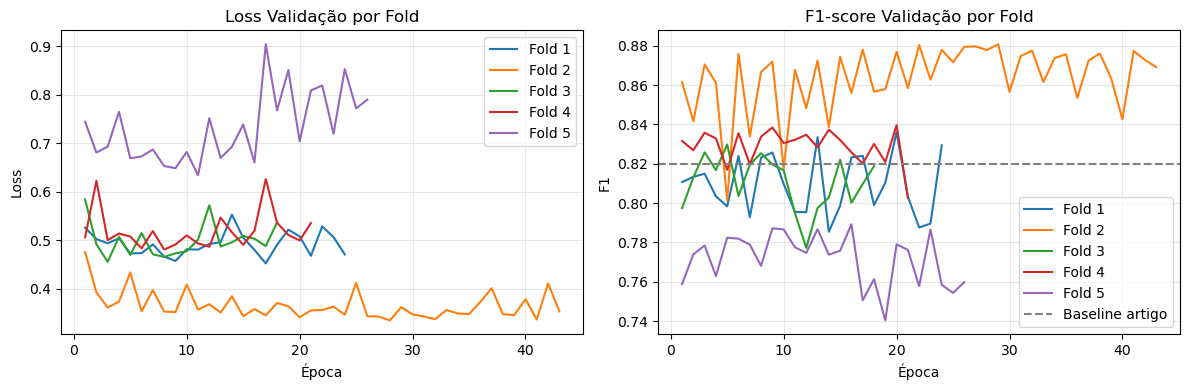

In [15]:
df_hist = pd.read_csv(PASTA_METRICS / 'historico_cnn.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fold in range(1, N_FOLDS + 1):
    d = df_hist[df_hist.fold == fold]
    axes[0].plot(d.epoca, d.loss_val,  label=f'Fold {fold}')
    axes[1].plot(d.epoca, d.f1_val,    label=f'Fold {fold}')

axes[0].set(title='Loss Validação por Fold', xlabel='Época', ylabel='Loss')
axes[1].set(title='F1-score Validação por Fold', xlabel='Época', ylabel='F1')
axes[1].axhline(0.82, color='gray', linestyle='--', label='Baseline artigo')
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PASTA_FIGURES / 'curvas_aprendizado_cnn.png', dpi=300)
plt.show()

---
## 7. Avaliação no Conjunto de Teste

Usa o modelo do fold com maior F1 de validação.

In [16]:
# Seleciona o melhor fold
melhor_fold = int(np.argmax(f1_folds)) + 1
print(f'Melhor fold: {melhor_fold} (F1 val = {f1_folds[melhor_fold-1]:.4f})')

modelo_final = CNN_Ruminacao(
    kernel=KERNEL_SIZE, dropout=DROPOUT,
    filtros=N_FILTROS
).to(DEVICE)

modelo_final.load_state_dict(
    torch.load(
        PASTA_CHECKPOINTS / f'modelo_fold{melhor_fold}.pt',
        map_location=DEVICE
    )
)

loader_teste = DataLoader(
    TensorDataset(X_teste, y_teste),
    batch_size=BATCH_SIZE, shuffle=False
)

criterio = nn.CrossEntropyLoss()
_, f1_teste, preds, labels = avaliar(modelo_final, loader_teste, criterio)

acc  = accuracy_score(labels, preds)
prec = precision_score(labels, preds, average='macro', zero_division=0)
rec  = recall_score(labels, preds, average='macro', zero_division=0)

print('\n══ Métricas no Conjunto de Teste (CNN 1D) ══')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 (macro): {f1_teste:.4f}')
print(f'  (Artigo   : Precision=0.84 | Recall=0.82 | F1=0.82)')
print()
print(
    classification_report(
        labels, preds,
        target_names=list(CLASSES.values()),
        zero_division=0
    )
)

Melhor fold: 2 (F1 val = 0.8778)

══ Métricas no Conjunto de Teste (CNN 1D) ══
  Accuracy  : 0.8273
  Precision : 0.7918
  Recall    : 0.8222
  F1 (macro): 0.7864
  (Artigo   : Precision=0.84 | Recall=0.82 | F1=0.82)

              precision    recall  f1-score   support

       Outro       0.92      0.90      0.91      9246
   Ruminação       0.96      0.73      0.83      6870
     Comendo       0.49      0.84      0.62      2712

    accuracy                           0.83     18828
   macro avg       0.79      0.82      0.79     18828
weighted avg       0.87      0.83      0.84     18828



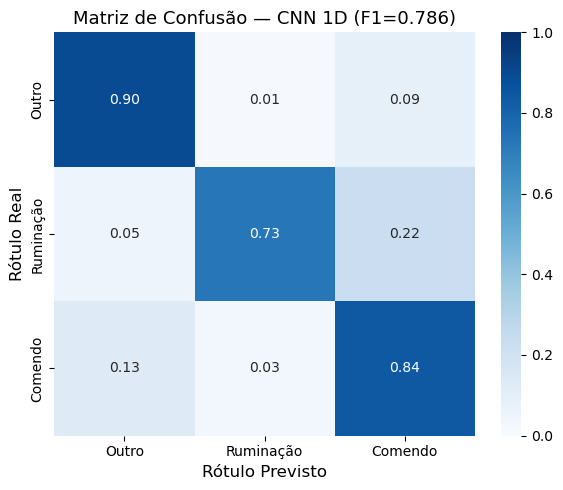

In [17]:
# Matriz de confusão normalizada
cm      = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=list(CLASSES.values()),
    yticklabels=list(CLASSES.values()),
    vmin=0, vmax=1, ax=ax
)
ax.set_xlabel('Rótulo Previsto', fontsize=12)
ax.set_ylabel('Rótulo Real',     fontsize=12)
ax.set_title(f'Matriz de Confusão — CNN 1D (F1={f1_teste:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig(PASTA_FIGURES / 'matriz_confusao_cnn.png', dpi=300)
plt.show()

In [18]:
# Salva resultados para uso no relatório comparativo
resultados_cnn = {
    'modelo'   : 'CNN 1D',
    'accuracy' : round(acc, 4),
    'precision': round(prec, 4),
    'recall'   : round(rec, 4),
    'f1_macro' : round(f1_teste, 4),
    'f1_folds' : f1_folds,
    'preds'    : preds.tolist(),
    'labels'   : labels.tolist(),
}

import json
with open(PASTA_METRICS / 'resultados_cnn.json', 'w') as f:
    json.dump(resultados_cnn, f, indent=2)

print('Resultados salvos em resultados_cnn.json')
print('Pronto para comparar com o Modelo 2 (Random Forest)')

Resultados salvos em resultados_cnn.json
Pronto para comparar com o Modelo 2 (Random Forest)
